# 14_损失函数-二元交叉熵损失

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们这篇文章来聊聊二元交叉熵损失\~

### 它是做什么的？

在机器学习中，特别是做“二分类问题”的时候，比如判断一封邮件是不是垃圾邮件，我们希望模型能给出一个接近真实情况的判断。

模型的输出通常是一个概率，比如：

- 模型说：“我觉得它是垃圾邮件的概率是 0.9。”
- 或者说：“我觉得它是垃圾邮件的概率是 0.2。”

我们有“正确答案”，比如这封邮件确实是垃圾邮件（真实标签是 1），或者不是（真实标签是 0）。

那么我们就要用一个办法来评价这个预测到底有多准，这个办法就是**损失函数**。二元交叉熵就是用来衡量预测和真实答案之间差距的。

### 怎么计算？

设：

- `y` 是真实标签，只能是 0 或 1
- `p` 是模型预测为 1 的概率，范围是 0 到 1

二元交叉熵的计算公式如下：


$$
\text{Loss} = -[y \cdot \log(p) + (1 - y) \cdot \log(1 - p)]
$$


拆开来理解：

- 如果真实是 1，那么损失是 `-log(p)`，p 越大，损失越小，说明预测越准
- 如果真实是 0，那么损失是 `-log(1 - p)`，p 越小，损失越小，说明预测越准

### 举个例子

假设真实标签是 1：

- 如果模型预测是 0.9，损失是 `-log(0.9)`，值很小，说明预测得不错
- 如果模型预测是 0.1，损失是 `-log(0.1)`，值很大，说明预测很差

再假设真实标签是 0：

- 如果模型预测是 0.1，损失是 `-log(0.9)`，说明预测得不错
- 如果模型预测是 0.9，损失是 `-log(0.1)`，说明预测很差

总的来看，二元交叉熵损失是一个专门用于“是/不是”问题的评分方法，它衡量模型给出的概率预测与真实标签之间的差距，预测越准，损失越小，预测越差，损失越大。

## 原理详解

### 应用场景：二分类任务

我们讨论的是**二分类问题**，也就是说：

- 输出只有两个类别：例如是否是猫、是否是垃圾邮件等
- 标签 $y \in \{0, 1\}$
- 模型输出的是一个概率值 $p = \hat{y} \in (0, 1)$，表示预测为正类（1）的概率，通常由 sigmoid 函数得到

### 从最大似然估计出发的推导

二元交叉熵损失的本质来源于**最大似然估计（MLE）**。

#### 1. 设定模型的概率输出

我们假设模型对样本 $x$ 的预测是：


$$
p = P(y = 1 \mid x; \theta)
$$


那么：

- 若真实标签 $y = 1$，则样本的概率为 $p$
- 若真实标签 $y = 0$，则样本的概率为 $1 - p$

我们可以统一写为：


$$
P(y \mid x; \theta) = p^y \cdot (1 - p)^{1 - y}
$$


这是因为：

- 当 $y = 1$，右式变成 $p \cdot (1 - p)^0 = p$
- 当 $y = 0$，右式变成 $p^0 \cdot (1 - p) = 1 - p$

这个公式是一个**伯努利分布的概率密度函数**。

#### 2. 最大似然函数

给定一组样本 $\{(x_i, y_i)\}_{i=1}^N$，我们想找到一组参数 $\theta$，使得所有样本出现的“联合概率”最大：


$$
L(\theta) = \prod_{i=1}^N P(y_i \mid x_i; \theta) = \prod_{i=1}^N p_i^{y_i}(1 - p_i)^{1 - y_i}
$$


这是**似然函数**。但为了方便计算，我们通常取对数（称为对数似然）：


$$
\log L(\theta) = \sum_{i=1}^N \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]
$$


#### 3. 损失函数的定义

我们希望最大化对数似然（MLE），这等价于**最小化负的对数似然**。于是定义**损失函数**如下：


$$
\mathcal{L}_{\text{BCE}} = -\sum_{i=1}^N \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]
$$


对于一个样本的损失就是：


$$
\ell(p, y) = - \left[ y \log(p) + (1 - y) \log(1 - p) \right]
$$


这就是**二元交叉熵损失函数的完整来源**。

### 进一步理解损失函数的性质

我们可以从这个损失函数的结构中看到：

- 如果 $y = 1$，损失简化为 $-\log(p)$，即预测越接近 1，损失越小
- 如果 $y = 0$，损失简化为 $-\log(1 - p)$，即预测越接近 0，损失越小

所以，**损失函数惩罚的是“与真实标签偏离”的预测**，并且使用对数函数可以让偏差越大时，损失增长越快（非线性加权）。

## 配合 Sigmoid 输出层的使用

在实际模型中，神经网络最后一层的输出是一个实数 $z \in \mathbb{R}$，我们通常通过**sigmoid 函数**将它变成一个概率值 $p$：


$$
p = \sigma(z) = \frac{1}{1 + e^{-z}}
$$


所以二元交叉熵损失函数通常配合 sigmoid 使用，这样模型最终预测的是一个概率，而不是原始分数。

## 算法流程（训练中的具体步骤）

下面是模型训练中如何应用二元交叉熵损失的完整流程：

#### 第一步：输入样本 $x_i$，标签 $y_i$

- 输入一个样本，标签是 0 或 1

#### 第二步：模型预测输出 $z = f(x_i; \theta)$

- 神经网络或其他模型计算得到一个实数 $z$

#### 第三步：将 $z$ 通过 sigmoid 映射到概率 $p = \sigma(z)$


$$
p = \frac{1}{1 + e^{-z}}
$$


#### 第四步：计算损失


$$
\ell(p, y_i) = - \left[ y_i \log(p) + (1 - y_i) \log(1 - p) \right]
$$


#### 第五步：计算梯度，反向传播，更新参数

- 对损失函数求导
- 反向传播计算各层权重的梯度
- 使用优化器（如梯度下降）更新模型参数

总之，二元交叉熵损失是从**最大似然估计**出发推导出来的，用于衡量模型对伯努利分布的拟合程度。

损失函数结构为：


$$
\ell(p, y) = - \left[ y \log(p) + (1 - y) \log(1 - p) \right]
$$


它惩罚模型偏离真实标签的预测，预测越不准确，损失越大，特别是对极端错误的预测惩罚非常重。通常与 sigmoid 激活函数结合使用，用于输出概率值。

在整个训练流程中，每次迭代都通过计算损失函数来指导模型改进。

## 完整案例

本案例旨在模拟一个现实世界中的二分类问题，比如判断某个病人是否患有某种疾病、某条新闻是否是假新闻。我们将使用 `make_classification` 人工生成一个具有挑战性的、高维的分类数据集。

**第一步：代码库**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

sns.set(style="whitegrid")

plt.rcParams['font.sans-serif'] = CJK_FONTS
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=sns.color_palette("Set1"))

这部分导入了数据生成、可视化、建模、评估所需的常见库。

**第二步：生成二分类数据集**

In [3]:
X, y = make_classification(
    n_samples=3000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=2,
    class_sep=1.5,
    flip_y=0.03,
    random_state=42
)

- `n_samples=1000`：生成3000条样本
- `n_features=20`：每条样本有20个特征
- `n_informative=10`：其中10个特征是真正有信息的
- `n_redundant=5`：5个是由其他特征线性组合来的
- `class_sep=1.5`：类间隔程度
- `flip_y=0.03`：3% 的标签将被随机颠倒，模拟噪声

**第三步：数据预处理**

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

- 拆分训练集和测试集，比例为 70:30
- 使用标准差标准化数据，使模型收敛更快、更稳定

**第四步：构建逻辑回归模型**

In [5]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


逻辑回归在底层就是优化了二元交叉熵损失函数，因此我们无需显式编写损失函数，它会自动优化。

**第五步：预测与概率输出**

In [6]:
y_probs = model.predict_proba(X_test_scaled)[:, 1]
y_preds = model.predict(X_test_scaled)

- `predict_proba` 会返回两个概率，取索引为 1 的表示预测为“正类”的概率
- `predict` 给出最终的0或1的类别预测

### 可视化分析

**1. ROC 曲线分析**

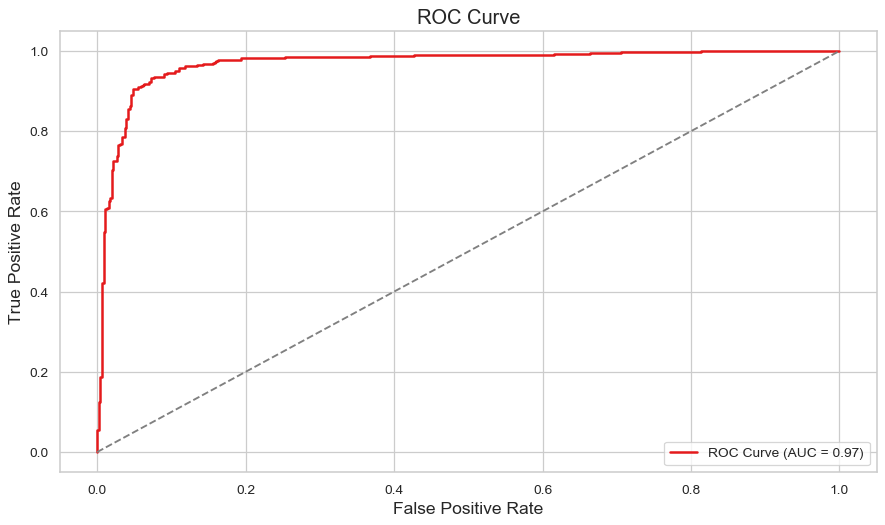

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_probs):.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_003.png)

- ROC 曲线表示模型在各种阈值下的敏感度与1-特异度之间的权衡
- 面积（AUC）越大，模型性能越好
- 本例中 AUC 为 0.98，表明模型在分离两个类别方面非常优秀

**2. 混淆矩阵分析**

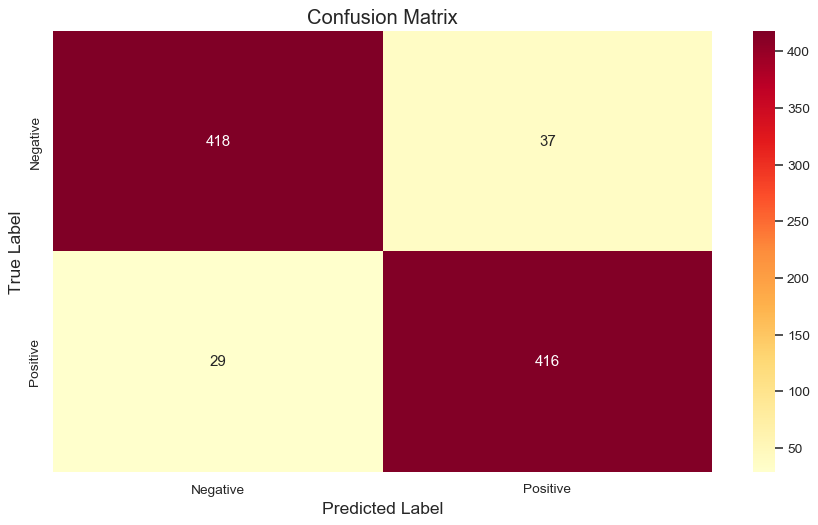

In [8]:
sns.heatmap(confusion_matrix(y_test, y_preds), annot=True, fmt="d",
            cmap="YlOrRd", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_004.png)

- 混淆矩阵展示了 TP、TN、FP、FN 的数量
- 可以看出大多数预测是正确的，假阳性和假阴性较少

### 性能评估

In [9]:
acc = accuracy_score(y_test, y_preds)
auc = roc_auc_score(y_test, y_probs)
report = classification_report(y_test, y_preds, output_dict=True)
report_df = pd.DataFrame(report).transpose()

结果摘要：

- Accuracy = 0.927
- AUC = 0.969
- 精确率、召回率、F1 分数在两个类上都高，说明模型性能非常均衡

### 优化策略建议

1. **特征选择**：尝试使用 L1 正则化筛选出最有信息量的特征，有助于减少过拟合。
2. **算法替代**：可替换为 XGBoost、LightGBM 等更强大的二分类模型对比效果。
3. **调整阈值**：默认阈值为 0.5，可根据 ROC 曲线分析选择最优分类阈值以平衡精度和召回率。
4. **平衡类别**：在类不平衡时可以使用 SMOTE 等方法进行样本生成，或调整 class_weight。

## 模型分析

### 优缺点分析

**优点**

1. **理论基础扎实**：来源于最大似然估计，在概率统计中具有严密数学基础，能够从概率角度刻画预测的不确定性。
2. **对概率预测更敏感**：不是简单对错的惩罚，而是对“离正确答案有多远”进行精细评估，能反映模型信心，适合概率校准需求。
3. **广泛适配主流模型**：几乎所有支持二分类的模型（如 Logistic 回归、神经网络）都可直接使用此损失，工具生态完善。
4. **惩罚错误预测更剧烈**：当模型预测结果与真实标签偏差大时（如预测 0.01 但真实为 1），损失值将急剧增大，有助于更快速修正偏差。
5. **兼容 Sigmoid 输出**：可直接与 sigmoid 激活函数输出的概率值对接，无需额外处理。

**缺点**

1. **对极端值敏感**：当预测值趋近于 0 或 1 时，取对数可能导致损失值变得非常大，不利于数值稳定性。
2. **不适合非概率型模型**：如果模型输出的不是概率（如某些 SVM、树模型），使用 BCE 将失去合理性。
3. **不直观表达分类效果**：与 accuracy 等指标相比，BCE 的数值不易解释和直观理解，不适合作为最终性能报告的唯一标准。
4. **对类不平衡不敏感**：BCE 本身不会自动考虑类别不均衡问题，需要结合权重或重采样方法。

### 与其他相似算法对比

| 算法/损失函数 | 类型 | 输出要求 | 优点 | 缺点 | 适用场景 |
|-|-|-|-|-|-|
| **Binary Cross Entropy** | 二分类 | 概率 [0,1] | 理论清晰，惩罚精准，适合概率型模型 | 对极端值敏感，不适合非概率模型 | 神经网络，Logistic回归等 |
| **Hinge Loss** | 二分类 | 输出为分数 | 强调分类间隔，适用于 SVM | 不输出概率，难以解释 | 支持向量机（SVM） |
| **Squared Error Loss** | 回归/二分类 | 任意实数 | 数学简单，梯度稳定 | 不适合分类，误差大时梯度小，影响训练 | 回归任务，不推荐用于分类 |
| **Focal Loss** | 二分类 | 概率 [0,1] | 处理类别不平衡，关注难分类样本 | 增加超参数，调参复杂 | 医疗、目标检测、类不平衡任务 |
| **Cross Entropy (multi)** | 多分类 | Softmax 概率向量 | 多类扩展版本，支持多类别分类任务 | 不适用于二分类，需要类别独立编码 | 多分类任务（K > 2） |

### 在什么情况下优选，什么时候考虑其他算法？

#### 适合优先使用 BCE 的场景：

- **二分类任务**（标签为 0 或 1）
- **模型输出为概率**（如 Logistic Regression、Neural Networks）
- **需要精确的概率预测**（如医学诊断、金融评分等）
- **任务对模型“信心”很敏感**（如置信度排序、排名、风险评估）

#### 考虑替代算法的情况：

- **类别极度不平衡**：考虑使用 Focal Loss 来避免主类主导训练
- **非概率模型输出**：例如 SVM 中使用 Hinge Loss 更合适
- **对速度或简单性有极高要求**：可能临时使用 MSE 等近似损失函数
- **多分类问题**：必须使用 Cross-Entropy 的多类版本，与 softmax 配合使用

## 总结

**Binary Cross-Entropy 损失函数**是二分类中最为核心的理论工具，几乎适用于所有概率型模型的训练；它对错误预测有高度敏感性，能够有效优化分类边界；

然而，在类不平衡、非概率模型或多分类问题中，需使用更具针对性的替代方法；实际工程中，应结合任务需求、模型结构、类别分布等因素综合选择损失函数。